In the name of God

# Q2: Robust Zero-Shot Classification

## 2-0 Introduction:

In this notebook we are going to implement different ways of adversarial attacks and comparing them, we will be following to work done in this paper (https://openreview.net/forum?id=P4bXCawRi5J)

## 2-1. Introduction to the CLIP Model, Zero-Shot Classification, and Adversarial Attacks

### 2-1-1. FGSM and PGD

Before we explain what FGSM and PGD are let's first briefly explain what are adversarial attacks:

__Adversarial attacks__: As the paper described, an adversarial attack adds a small imperceptible perturbation to an original image to create a new image with the goal of crafting an image to maximize the model's prediction error or loss.

__Fast Gradient Sign Method (FGSM)__:
    (based on this intro from tensor flow: https://www.tensorflow.org/tutorials/generative/adversarial_fgsm)
    FGSM is a fast method for generating adversarial examples. It works by exploiting how the model's loss function behaves to maximize the model's loss by making only a single change to the input image. (each pixel)
    The process involves the following steps:
        
* Calculating the gradient: FGSM first calculates the gradient of the model's loss function with respect to the pixels of the input image to find the direction in which to change the pixel values to achieve the maximum increase in the loss.
        
* Finding the sign: Instead of using the gradient values, FGSM only uses the sign of each element in the gradient. meaning for each pixel it determines if the value should be increased (+1) or decreased (-1) to maximize the loss.
        
* Apply the perturbation: The sign vector is then multiplied by a small scalar epsilon, that controls the overall magnitude of the perturbation.

The formula is:

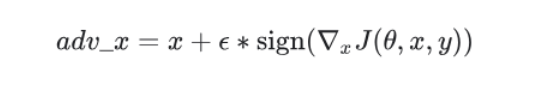



__Projected Gradient Descent (PGD)__:
    According to this article on medium (https://medium.com/@zachariaharungeorge/unveiling-the-power-of-projected-gradient-descent-in-adversarial-attacks-2f92509dde3c)
    PGD is an iterative extension of the basic adversarial idea. Instead of taking one large step, PGD takes multiple smaller steps that make it more likely to find a successful perturbation.

The process consists of the following steps:

* Initialization: It starts by taking a small and random step away from the original image but still within the allowed area.

* Iterative Steps: For a number of steps it calculates the gradient just like in FGSM, and the gradient of the loss is calculated with respect to the current pixels of the perturbed image. Then it takes a small step in the direction of the gradient's sign. the size of this step is determined by a step size parameter, denoted as alpha. (for example in the paper, they used a step size of alpha = 1/255 for their PGD attacks.) After each step, the new perturbed image may have moved outside the allowed area around the original image. The projection step forces the image back into this boundary by clipping the perturbation to ensure its magnitude does not exceed the allowed value (epsilon).
        
Because PGD is an iterative process that explores the area around the image more thoroughly, it is considered a much stronger attack than FGSM and is a standard benchmark for evaluating a model's adversarial robustness.

### 2-1-2. CLIP

#### 2-1-2-1. CLIP Architecture

The idea behind CLIP (Contrastive Language-Image Pre-training) is to learn a multi-modal embedding space where images and text that are similar (in context) are located close to one another. To achieve this, the model is composed of two main encoders, an image encoder and a text encoder.

* __Image Encoder__: This component takes an image as input and outputs a feature vector. In the paper that introduced CLIP two different architectures were considered for this encoder:

    A modified version of the ResNet-50 architecture. Where the key modifications included using ResNet-D improvements, antialiased rect-2 blur pooling, and replacing the global average pooling layer with an attention pooling mechanism.

    And a Vision Transformer (ViT) as an alternative architecture that processed an image as a sequence of flattened patches.

* __Text Encoder__: This component takes a text as input and generates a corresponding feature vector. The architecture used is a 63M-parameter transformer with 12 layers and 8 attention heads.

Both encoders are trained jointly from scratch to project their outputs into the same embedding space. A summary of the model architecture can bee seen in the image below:

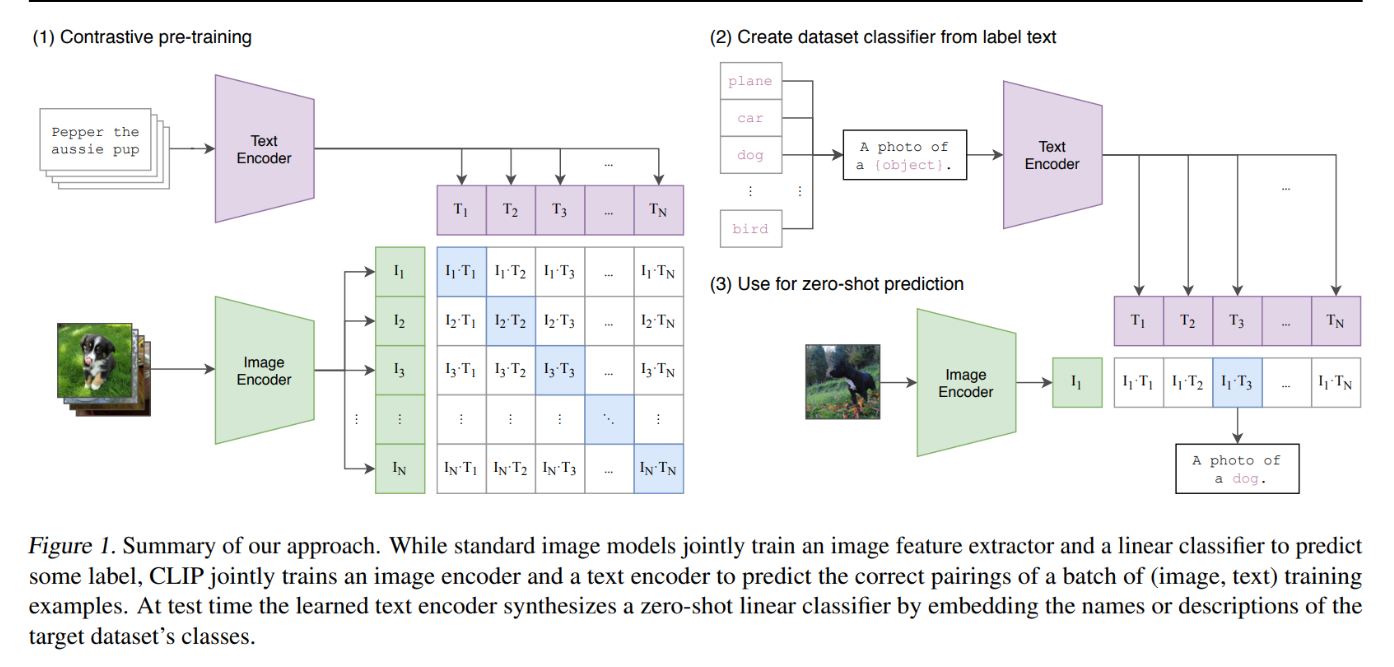

#### 2-1-2-2. Contrastive Training

Instead of using a traditional objective, like trying to predict the exact text caption for an image, CLIP uses a contrastive objective. The goal isn't to generate content, but rather to match existing images and texts from a large batch.

The process, has the following steps (as shown in the image of last section):

* __Create a Batch__
    
* __Encode Everything__

* __Calculate Similarity__: The model computes the cosine similarity between every image embedding and every text embedding. This creates a large N x N matrix of similarity scores .

* __The Contrastive Goal__: Along the diagonal of this matrix lie the similarity scores for the correct (image, text) pairs and the remaining entries in the matrix are the similarity scores for all the incorrect pairings. The model's training objective is to maximize the similarity of the N correct pairs while minimizing the similarity of the rest of the pairs.

In a nutshell the model it learns to associate an image with its correct caption from.

#### 2-1-2-3. Loss Function

The model uses Symmetric Cross-Entropy Loss Function

To accomplish the contrastive training described above, CLIP uses what the paper it was introduced in calls a "symmetric cross entropy loss". This is detailed in the image below.

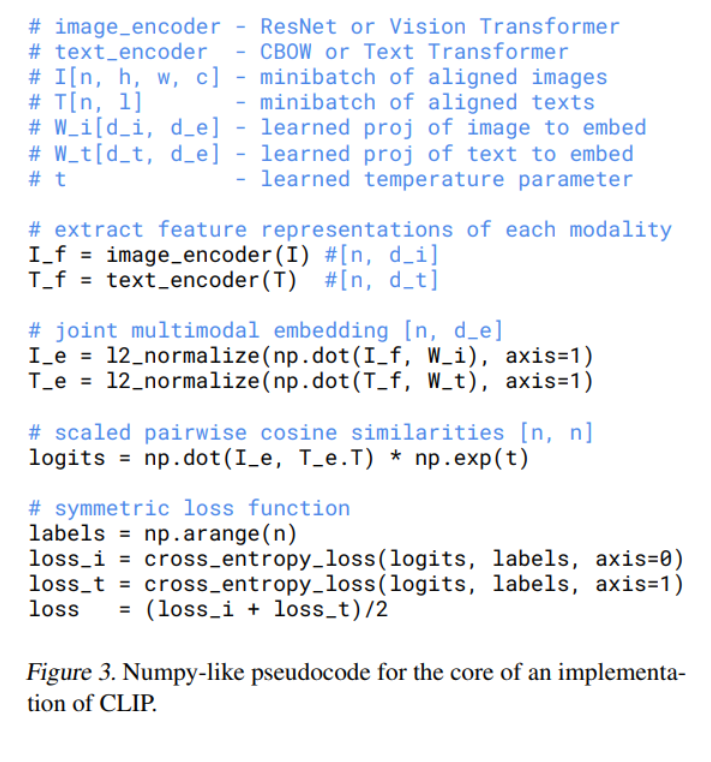![image.png](attachment:image.png)

The "symmetric" part means the loss is calculated from two perspectives, and then averaged:

* __Image-to-Text Loss (loss_i)__: For each image in the batch, this loss treats the task as a classification problem. The goal is to correctly classify which of the text snippets is the true match and standard cross-entropy loss is used to optimize this prediction.

* __Text-to-Image Loss (loss_t)__: For each text in the batch, the model must correctly classify which of the N images is its true partner. This also uses a cross-entropy loss.

The final loss for the entire batch is the average of these two individual losses:

loss = (loss_i + loss_t) / 2

### 2-1-3. Zero-Shot vs Normal Classification

The primary difference is in how the models are trained and what they can predict.

__Normal (Supervised) Classification__ is the traditional approach in computer vision where a model is trained on a dataset with a fixed and predetermined set of labels. So to classify a new category, the model must be retrained or fine-tuned with additional labeled examples for that specific category. The output is typically a static softmax classifier that predicts from the limited set of classes it has seen during training.

__Zero-Shot Classification__ is an approach that allows a model to be much more flexible and general. With this approach a model can classify images into unseen categories that it was not explicitly trained on. In order to achieve this instead of learning from a fixed set of labels, it learns a more general association between visual data and descriptive language. This enables the model to transfer its knowledge to new tasks and datasets without needing additional dataset-specific training.

Basically, a normally trained classifier can only identify what it has already been taught to see, while a zero-shot classifier can identify new concepts described to it through language.

CLIP achieves zero-shot classification similarly by using its jointly trained image and text encoders to create a classifier from natural language descriptions at test time.

The process is illustrated in parts (2) and (3) of figure below:

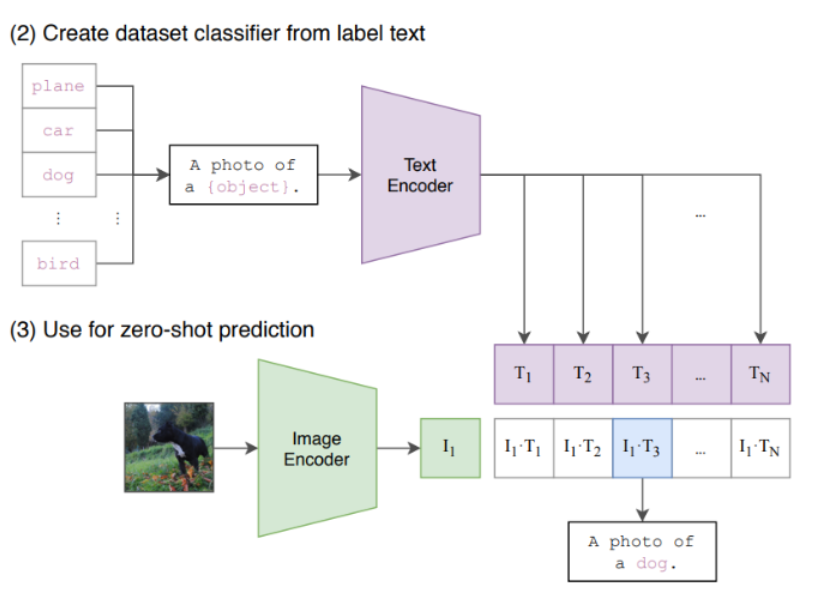

(2) Create dataset classifier from label text
(3) Use for zero-shot prediction

Here is a step-by-step breakdown of this process:

__Create the Classifier from Text__ (Part 2 of Diagram): For any given classification task, the names of all possible target classes are first defined (e.g., "plane", "car", "dog"). Then to provide context, these class names are embedded into prompt templates, such as "A photo of a {label}.". These descriptive prompts are then fed into CLIP's text encoder to generate a set of text embeddings (feature vectors). These embeddings then become the weights of a new, "zero-shot" linear classifier.

__Encode the image__ (Part 3 of Diagram): The input image that needs to be classified is passed through CLIP's Image Encoder to produce a single image embedding.

Compare Embeddings for Prediction (Part 3 of Diagram): The model calculates the cosine similarity between the image embedding and all of the text embeddings (the classifier weights) created in step 1.

__Final Classification__: The class corresponding to the text prompt with the highest cosine similarity is the model's final prediction. Because this classifier is synthesized "on-the-fly" using natural language, CLIP can perform classification on arbitrary new tasks without being retrained.

### 2-1-4. Adversarial Attack Types

In the field of machine learning security, adversarial attacks are categorized based on how much information the attacker has about the target model. The two primary categories are white-box and black-box.

* __White-Box Attacks__: In this scenario, the attacker has full knowledge of the target model. This includes having the source code, the model's architecture, its parameters and the loss function used for training.Because of this complete access, attackers can use powerful gradient-based methods like the Fast Gradient Sign Method (FGSM) and Projected Gradient Descent (PGD) to precisely calculate the most efficient perturbation to fool the model.

* __Black-Box Attacks__: In this scenario, the attacker has no access to the model's internal workings. The model is treated as a "black box". The attacker can only provide an input to the model and observe the corresponding output (like the predicted class label and confidence score). Since the attacker cannot directly calculate the model's gradients, they must use other strategies. Common black-box methods include query-based attacks (making many queries to infer the model's decision boundary) and transfer attacks, which are a significant threat in real-world applications.

We can see a detailed table comparing these two (generated by and AI based on the description above)

| Aspect       | White-Box Attacks                                                                                     | Black-Box Attacks                                                                                                             |
|--------------|--------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------|
| Knowledge    | Complete access to the model's architecture, parameters, and gradients.                               | No internal knowledge; only input-output access is available.                                                               |
| Effectiveness| Highly effective. These attacks are optimized for the specific model and represent a "worst-case" scenario for testing robustness. | Less effective than white-box attacks. The success rate is lower and depends heavily on the attack strategy (e.g., the quality of a substitute model in a transfer attack). |
| Methodology  | Primarily use gradient-based methods like FGSM and PGD to craft perturbations.                        | Rely on query-based or transfer-based methods to estimate or bypass the need for gradients.                                 |



### 2-1-5. Transfer Attacks

Based on this article on medium (https://medium.com/google-developer-experts/cybersecurity-in-ai-transfer-learning-as-an-attack-vector-a6703b017337):

While white-box attacks are more powerful against a specific model, their real-world application are limited. Transfer attacks, however, represent a more serious and practical threat for the following reasons:

1.__Real-World Systems are Black Boxes__: In most real-world scenarios, models deployed by companies are proprietary. Attackers do not have access to the model's architecture, parameters, or gradients. This makes a direct white-box attack, which requires this internal knowledge, impossible. Transfer attacks are a method for attacking these realistic black-box systems.

2.__No Internal Access Required__: A transfer attack bypasses the need for internal knowledge. The attacker can simply train their own local model (which is a white-box to them). use powerful white-box methods like PGD to generate an adversarial example that fools their own model and transfer this same adversarial example to the target black-box system.

3.__Vulnerabilities are General, Not Specific__: The core reason transfer attacks work is that adversarial examples often exploit fundamental features or flaws in how neural networks learn, rather than targeting a single model's specific weights. Different models trained on similar tasks tend to learn similar feature representations, making them vulnerable to the same adversarial perturbations. According to the paper research has shown that adversarial properties are transferable across different models and tasks.

### 2-1-6. LORA

LoRA, which stands for Low-Rank Adaptation, is a parameter-efficient fine-tuning method designed to make the adaptation of large scale language models to specific downstream tasks more manageable and less computationally expensive.

The core idea is based on the hypothesis that the change in the weights of a model during adaptation has a low intrinsic rank meaning that the update to the weight matrix doesn't need to be a full-rank matrix and it can be effectively represented by a much smaller number of parameters. Instead of retraining all the parameters of a large pre-trained model (full fine-tuning), LoRA works as by using the following steps:

1.  __Freeze Pre-trained Weights__: The majority of the model's original, pre-trained weights are frozen and do not receive any gradient updates.

2.  __Inject Low-Rank Matrices__: For a given weight matrix in the model, LoRA injects a pair of smaller, trainable "rank decomposition" matrices, referred to as A and B.

3.  __Train Only the Injected Matrices__: During fine-tuning, only these newly added low-rank matrices A and B are trained. The product of these two smaller matrices, BA, represents the change (ΔW) to the original weight matrix (W0). The final output is the sum of the original weights and the learned adaptation: h = W₀x + BAx.

4.  __Merge for Deployment__: After training, the learned matrix BA can be merged with the original weight matrix W0 by simple addition (W = W0 + BA) to get the final, adapted weights. This means no extra parameters or calculations are needed during inference.

This can be seen in the picture below (from LoRA paper)

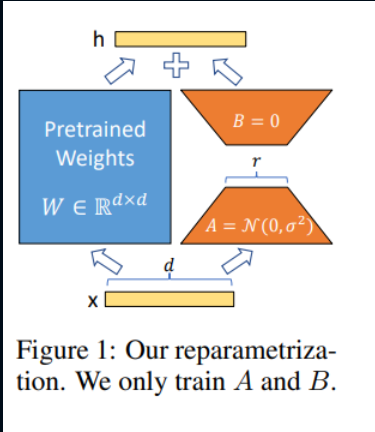


__Three Reasons for Using LoRA__

The LoRA paper highlights several key advantages of LoRA compared to other methods like full fine-tuning or adapter methods. Here are three of them:

1.  __It is extremely parameter-efficient.__ LoRA drastically reduces the number of trainable parameters required for task adaptation. Compared to fully fine-tuning GPT-3 175B, LoRA can reduce the number of trainable parameters by a factor of 10,000. This also reduces the checkpoint size from hundreds of gigabytes to a few megabytes.

2.  __It introduces no additional inference latency.__ Unlike adapter methods, which insert new layers that must be processed sequentially and thus add latency, LoRA is designed to be latency-free. Because the learned matrices (BA) can be merged directly into the original weights (W0) after training, the deployed model has the exact same number of parameters and the same architecture as the original pre-trained model.

3.  __It makes training more efficient and accessible.__ LoRA can speed up training and lower the hardware barrier to entry. On GPT-3 175B, LoRA reduces the VRAM requirement by a factor of 3 and can result in a 25% training speedup compared to full fine-tuning, as gradients do not need to be computed for the vast majority of frozen parameters. This makes the fine-tuning process faster and accessible on less powerful hardware.

### 2-1-7. Two Papers that Expand CLIP

#### 2-1-7-1. Paper 1: Post-pre-training for Modality Alignment in Vision-Language Foundation Models

This paper introduces CLIP-Refine, a post-pre-training method designed to improve the performance of existing CLIP models by addressing the modality gap (the discrepancy between how images and text are clustered in the feature space). The authors propose a lightweight training phase that occurs after the initial pre-training but before any fine-tuning. This method uses two novel techniques: __Random Feature Alignment (RaFA)__ and __Hybrid Contrastive-Distillation (HyCD)__. RaFA encourages the image and text features to align to a common distribution, while HyCD uses a mix of ground-truth labels and knowledge from the original CLIP model to learn new information without forgetting what was previously learned. This approach requires minimal training, needing only one epoch on small datasets.

The CLIP-Refine loss function significantly improves CLIP's zero-shot performance across various tasks. By mitigating the modality gap and enhancing feature uniformity, the model becomes more effective at generalizing to new, unseen data. Experiments show that CLIP-Refine consistently outperforms the standard pre-trained CLIP model in zero-shot classification and retrieval tasks. For instance, on 12 classification datasets, CLIP-Refine increased the average accuracy from 52.74% to 54.69%. The method not only reduces the gap between image and text features but also improves the overall quality of the feature space, leading to more robust and accurate zero-shot capabilities.

#### 2-1-7-2. Paper 2: Post-pre-training for Modality Alignment in Vision-Language Foundation Models

This paper introduces __FairerCLIP__, a method designed to mitigate biases in the zero-shot predictions of CLIP models. It addresses biases stemming from both intrinsic dependencies (like correlations between gender and facial features) and spurious correlations (like image backgrounds). The core of FairerCLIP is a debiasing process that operates in a mathematical space known as a Reproducing Kernel Hilbert Space (RKHS). This approach allows it to define an objective function that explicitly aims to reduce the statistical dependence on sensitive attributes (like race or gender) while preserving information about the target attribute and maintaining the alignment between image and text features. A key advantage is its flexibility; it can be trained with or without ground-truth labels and is computationally efficient, leveraging closed-form solutions for optimization.

The FairerCLIP method effectively reduces bias while maintaining or even improving CLIP's zero-shot classification accuracy. By making the model's predictions more robust and fair, it enhances the reliability of its zero-shot capabilities. For instance, in experiments on datasets with intrinsic dependencies, FairerCLIP drastically reduced the Equal Opportunity Difference (EOD) fairness metric to near-zero while keeping classification accuracy high. Similarly, on datasets with spurious correlations, it consistently improved the worst-group accuracy and reduced the performance gap between different demographic groups. This demonstrates that the debiasing function not only makes predictions fairer but also leads to more robust performance in challenging zero-shot scenarios.

## 2-2. Implementation and Comparison of Adversarial Training Methods

### 2-2-1. Data Preparation

Here we will download the data of CIFAR-10 dataset using torchvision, split it into training validation and test sets, transform them for CLIP and display a batch of random sample from the data.

#### 2-2-1-1. Downloading & Transforming the Data

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms


clip_mean = [0.48145466, 0.4578275, 0.40821073]
clip_std = [0.26862954, 0.26130258, 0.27577711]

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=clip_mean, std=clip_std),
])

full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                  download=True, transform=transform)

train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                                 download=True, transform=transform)

print(f"Full training set size: {len(full_train_dataset)}")
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")


batch_size = 32

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                           shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=False, num_workers=2)

Full training set size: 50000
Training set size: 45000
Validation set size: 5000
Test set size: 10000


#### 2-2-1-2. Visualising the Transformed and Untransformed data

Labels:  bird  truck dog   ship  bird  ship  horse cat  


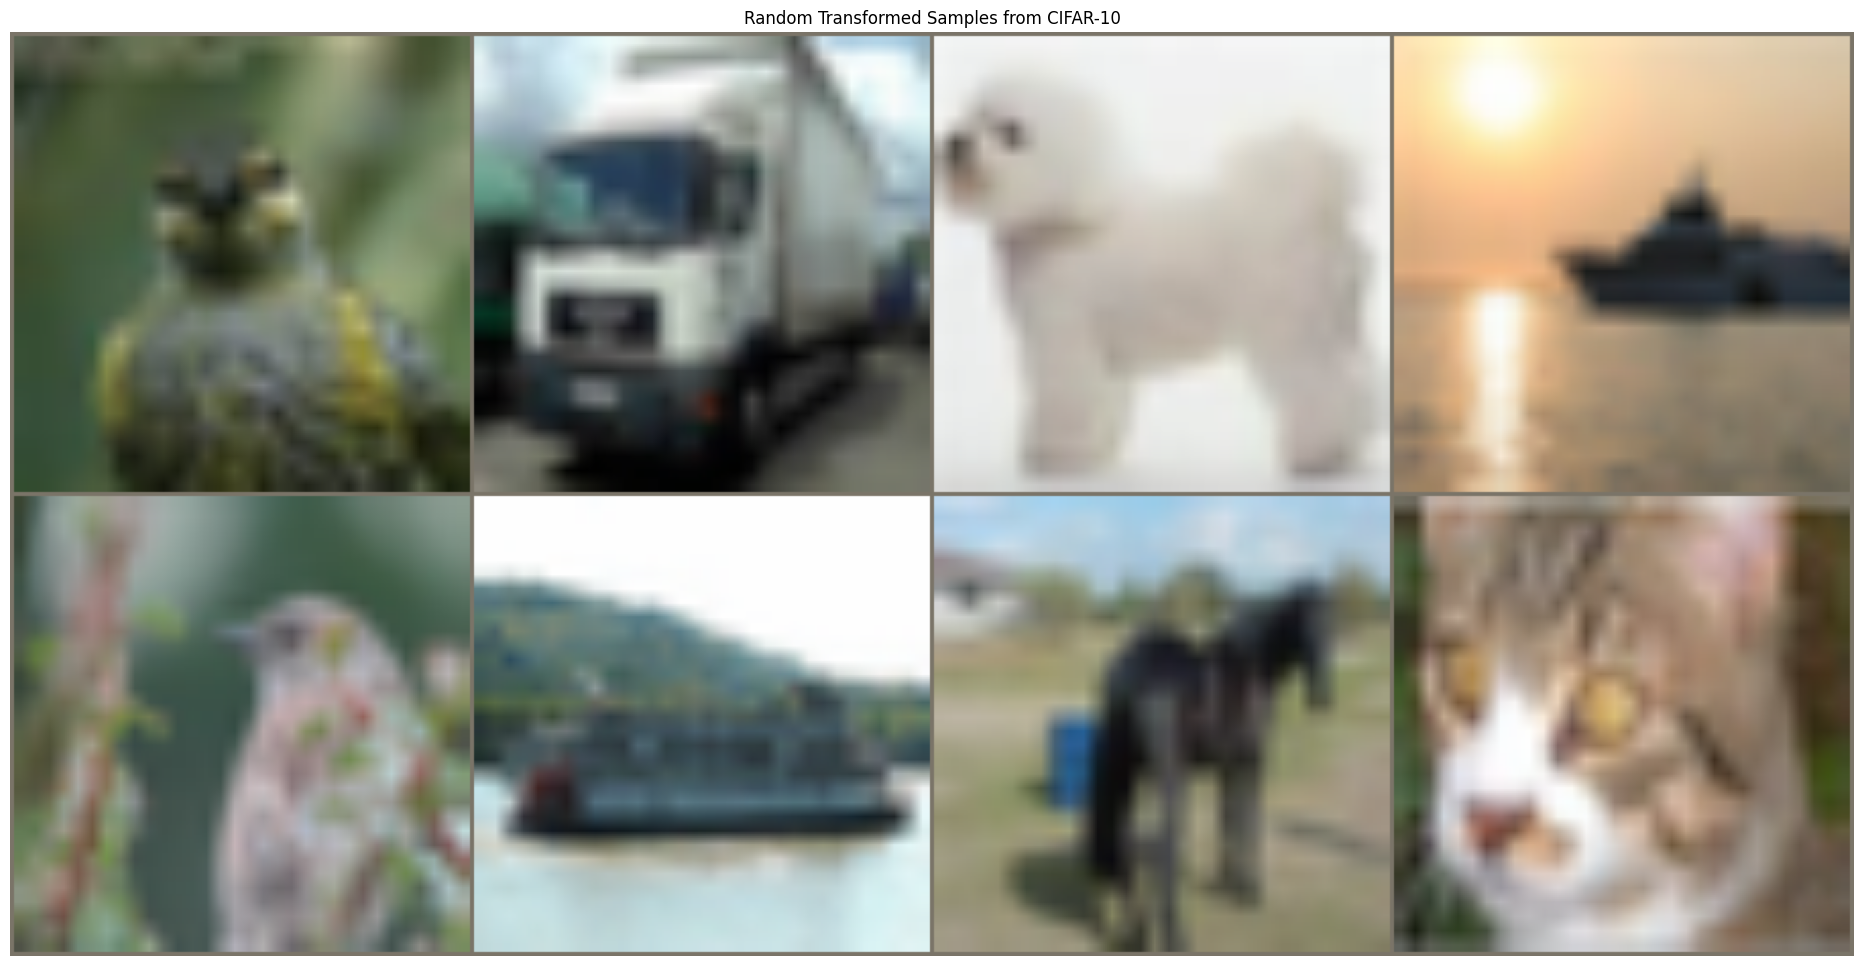

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

def show_random_samples(data_loader, label):
    images, labels = next(iter(data_loader))

    image_grid = torchvision.utils.make_grid(images[:8], nrow=4)

    image_grid = image_grid.numpy().transpose((1, 2, 0))
    image_grid = np.array(clip_std) * image_grid + np.array(clip_mean)
    image_grid = np.clip(image_grid, 0, 1)

    plt.figure(figsize=(24, 12))
    plt.imshow(image_grid)
    plt.title(label)
    plt.axis('off')

    print('Labels: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))
    plt.show()

show_random_samples(train_loader, "Random Transformed Samples from CIFAR-10")

### 2-2-2. Model Preparation

Here we will load the pre-trained CLIP model from Hugging Face transformers library, load the pre-trained CIFAR-10 ResNet-20 model from pytorch hub, set both models to eval mode, create the descriptive text prompt for CLIP based on CIFAR-10 class names and use CLIP to process these prompts and generate the text feature vectors needed for zero-shot classification.

#### 2-2-2-1. Setting up the Device & Loading CLIP

In [ ]:
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

clip_model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_model_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)

clip_model.eval()

Using device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

#### 2-2-2-2. Loading ResNet-20 model

In [ ]:

target_model = torch.hub.load(
    "chenyaofo/pytorch-cifar-models",
    "cifar10_resnet20",
    pretrained=True
).to(device)

target_model.eval()

Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

#### 2-2-2-3. Preparing the Textual Space for CLIP

In [ ]:
cifar_classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

text_prompts = [f"a photo of a {c}" for c in cifar_classes]

with torch.no_grad():
    inputs = clip_processor(text=text_prompts, return_tensors="pt", padding=True).to(device)

    text_features = clip_model.get_text_features(**inputs)

    text_features /= text_features.norm(dim=-1, keepdim=True)

print(f"Shape: {text_features.shape}")

Shape: torch.Size([10, 512])


### 2-2-3. Testing CLIP, PGD attack & Visualisation

Here we will first evaluate CLIP on clean data, then use a PGD attack with the given parametrs and evaluate CLIP on this attack data again and visualise some of the attack samples.

### 2-2-3-1. Evaluation Function

In [ ]:
from tqdm import tqdm

def evaluate_clip(model, dataloader, text_features, attack_model=None):
    model.eval()

    total_correct = 0
    total_samples = 0

    for images, labels in tqdm(dataloader, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)

        if attack_model:

            images = attack_model(images, labels)

        with torch.no_grad():
            image_features = model.get_image_features(pixel_values=images)

            image_features /= image_features.norm(dim=-1, keepdim=True)

            similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

            _, predictions = similarity.max(1)

            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    accuracy = 100.0 * total_correct / total_samples
    return accuracy

### 2-2-3-2. Evaluating CLIP

In [ ]:
clean_accuracy = evaluate_clip(clip_model, test_loader, text_features)
print()
print(f"CLIP's Zero-Shot Accuracy on clean CIFAR-10 images: {clean_accuracy:.2f}%")

Evaluating: 100%|██████████| 313/313 [00:28<00:00, 10.87it/s]


CLIP's Zero-Shot Accuracy on clean CIFAR-10 images: 87.83%


### 2-2-3-3. PGD Attack

In [ ]:
# !pip install torchattacks
import torchattacks

pgd_attack = torchattacks.PGD(target_model, eps=8/255, alpha=2/255, steps=7)

pgd_attack.set_normalization_used(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])

adversarial_accuracy = evaluate_clip(clip_model, test_loader, text_features, attack_model=pgd_attack)
print()
print(f"CLIP's Zero-Shot Accuracy on adversarial images: {adversarial_accuracy:.2f}%")

Evaluating: 100%|██████████| 313/313 [06:04<00:00,  1.17s/it]


CLIP's Zero-Shot Accuracy on adversarial images: 84.56%


### 2-2-3-4. Visualising a Single Attack Example

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

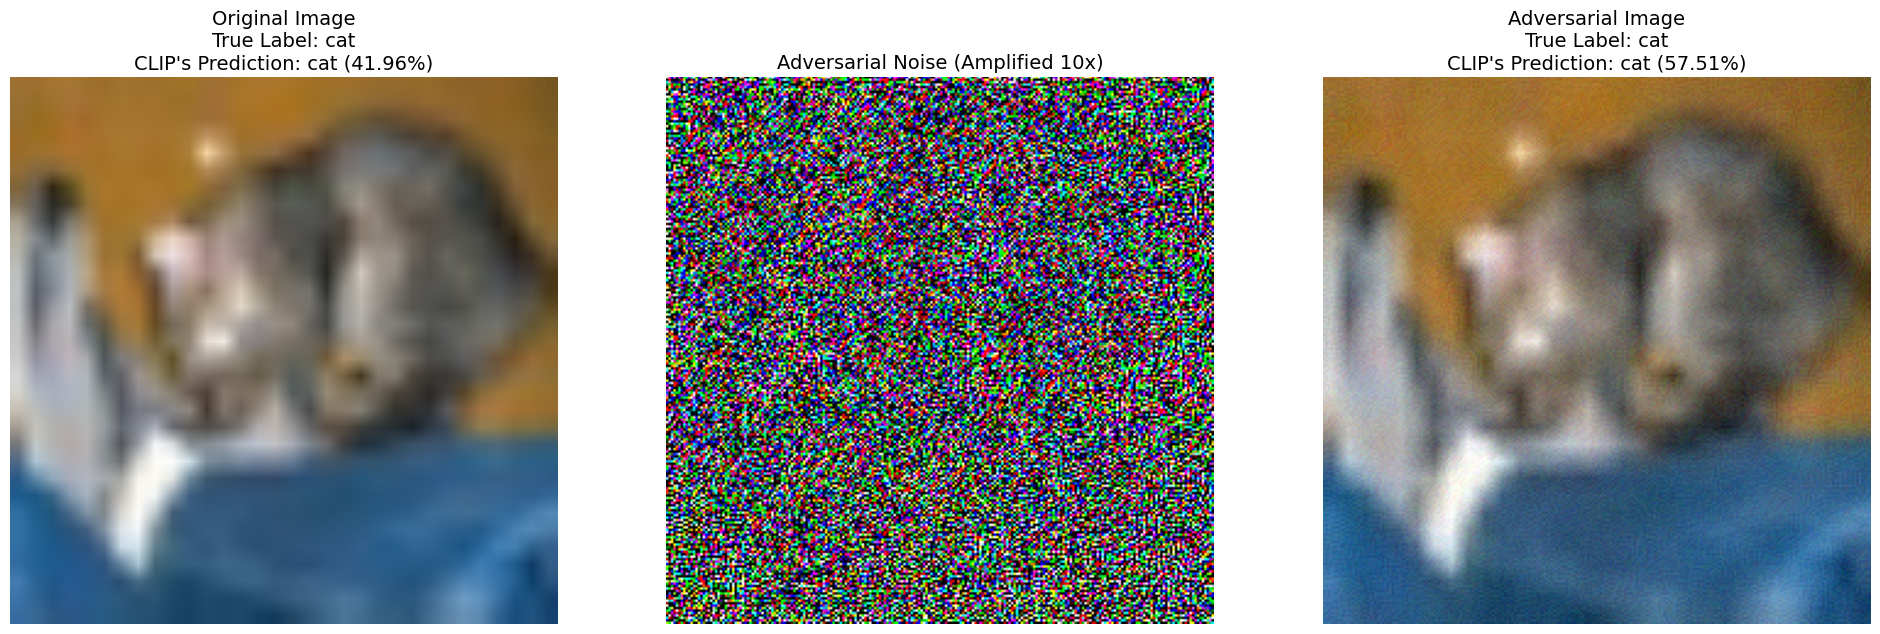

In [ ]:
original_image, label = next(iter(test_loader))
original_image, label = original_image[0:1].to(device), label[0:1].to(device)

adv_image = pgd_attack(original_image, label)

perturbation = (adv_image - original_image) * 10

def unnormalize(tensor, mean, std):
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

with torch.no_grad():
    pred_orig = clip_model.get_image_features(pixel_values=original_image)
    pred_orig /= pred_orig.norm(dim=-1, keepdim=True)
    probs_orig = (100.0 * pred_orig @ text_features.T).softmax(dim=-1)
    top_prob_orig, top_class_orig = probs_orig.topk(1, dim=-1)

    pred_adv = clip_model.get_image_features(pixel_values=adv_image)
    pred_adv /= pred_adv.norm(dim=-1, keepdim=True)
    probs_adv = (100.0 * pred_adv @ text_features.T).softmax(dim=-1)
    top_prob_adv, top_class_adv = probs_adv.topk(1, dim=-1)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Original Image
axes[0].imshow(unnormalize(original_image.squeeze(0).cpu(), clip_mean, clip_std).permute(1, 2, 0))
axes[0].set_title(
    f"Original Image\n"
    f"True Label: {classes[label.item()]}\n"
    f"CLIP's Prediction: {classes[top_class_orig.item()]} ({top_prob_orig.item()*100:.2f}%)",
    fontsize=14
)
axes[0].axis('off')

# Noise
axes[1].imshow(perturbation.squeeze(0).cpu().permute(1, 2, 0))
axes[1].set_title("Adversarial Noise (Amplified 10x)", fontsize=14)
axes[1].axis('off')

# Adversarial Image
axes[2].imshow(unnormalize(adv_image.squeeze(0).cpu(), clip_mean, clip_std).permute(1, 2, 0))
axes[2].set_title(
    f"Adversarial Image\n"
    f"True Label: {classes[label.item()]}\n"
    f"CLIP's Prediction: {classes[top_class_adv.item()]} ({top_prob_adv.item()*100:.2f}%)",
    fontsize=14
)
axes[2].axis('off')

### 2-2-4. LoRA

In this section we will define a define a LoraConfig to adapt the vision layers of the CLIP model, wrap the CLIP model with the LoRA configuration to create a new model, run a single training epoch, where for each batch, it generates adversarial examples and updates only the LoRA weights and finally, re-evaluates the newly fine-tuned model on both clean and adversarial test data to measure the change in robustness.

#### 2-2-4-1. Setting up LoRA

In [ ]:
# !pip install peft

from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
)

lora_model = get_peft_model(clip_model, lora_config)

lora_model.print_trainable_parameters()


trainable params: 491,520 || all params: 151,768,833 || trainable%: 0.3239


/usr/local/lib/python3.11/dist-packages/peft/mapping_func.py:73: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/peft/tuners/tuners_utils.py:167: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


#### 2-2-4-2. Adversarial Training with LoRA

In [ ]:
import torch.nn as nn
import torch.optim as optim

loss_function = nn.CrossEntropyLoss()
optimizer = optim.AdamW(lora_model.parameters(), lr=5e-5)

lora_model.train()
num_epochs = 1

for epoch in range(num_epochs):
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}")

    for batch in progress_bar:
        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        adv_images = pgd_attack(images, labels)

        image_features = lora_model.get_image_features(pixel_values=adv_images)

        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        logits = 100.0 * image_features @ text_features.T

        loss = loss_function(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        progress_bar.set_postfix({"loss": loss.item()})

Epoch 1/1: 100%|██████████| 1407/1407 [29:57<00:00,  1.28s/it, loss=0.669]


#### 2-2-4-3. Re-evaluation

In [ ]:
lora_model.eval()

tuned_clean_accuracy = evaluate_clip(lora_model, test_loader, text_features)
print()
print(f"Fine-tuned CLIP's accuracy on clean images: {tuned_clean_accuracy:.2f}%")

tuned_adversarial_accuracy = evaluate_clip(lora_model, test_loader, text_features, attack_model=pgd_attack)
print()
print(f"Fine-tuned CLIP's accuracy on adversarial images: {tuned_adversarial_accuracy:.2f}%")


print(f"Initial Clean Accuracy: {clean_accuracy:.2f}%")
print(f"Initial Adversarial Accuracy: {adversarial_accuracy:.2f}%")
print("After LoRA Adversarial Training:")
print(f"Clean Accuracy: {tuned_clean_accuracy:.2f}%")
print(f"Adversarial Accuracy: {tuned_adversarial_accuracy:.2f}%")

Evaluating: 100%|██████████| 313/313 [00:33<00:00,  9.48it/s]



Fine-tuned CLIP's accuracy on clean images: 94.95%


Evaluating: 100%|██████████| 313/313 [06:09<00:00,  1.18s/it]


Fine-tuned CLIP's accuracy on adversarial images: 96.82%
Initial Clean Accuracy: 87.83%
Initial Adversarial Accuracy: 84.56%

After LoRA Adversarial Training:
Clean Accuracy: 94.95%
Adversarial Accuracy: 96.82%


As we can see the model's accuracy has improved signifficantly after fine-tuning. After this adversarial training, the model even performs better on the adversarial attacks than the normal images!

It should be noted though our approach is slightly different than the paper, in the paper they did the adversarial training on the original dataset where clip was trained on (ImageNet if I'm not mistaken) and then tested it's adversarial defence on other zero-shot tasks, but due to the hardware and time constraints we fine-tuned the model on the same dataset as we are performing the test, so it's not very zero-shot anymore! (but even on this rather smaller dataset the process took a very long time!)

### 2-2-5. TeCoA

In this section we will be implementing the TeCoA (Text-guided Contrastive Adversarial Training) as explained in the earlier sections. After training (Fine tuning) the model again with this loss, we will re-evaluate its performance simllar to what we did in the last section.

#### 2-2-5-1. Adversarial Training with TeCoA

In [ ]:
import torch.nn.functional as F

lora_model.train()
num_epochs = 1

temperature = 0.07

for epoch in range(num_epochs):
    progress_bar = tqdm(train_loader, desc=f"TeCoA Epoch {epoch + 1}/{num_epochs}")

    for batch in progress_bar:
        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        adv_images = pgd_attack(images, labels)

        adv_image_features = lora_model.get_image_features(pixel_values=adv_images)


        # Instead of getting logits for classification against all 10 classes,
        # TeCoA computes a within-batch contrastive loss.

        batch_text_features = text_features[labels]

        adv_image_features = F.normalize(adv_image_features, p=2, dim=-1)
        batch_text_features = F.normalize(batch_text_features, p=2, dim=-1)

        similarity_matrix = adv_image_features @ batch_text_features.T / temperature

        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)

        loss = F.cross_entropy(similarity_matrix, ground_truth)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        progress_bar.set_postfix({"tecoa_loss": loss.item()})

TeCoA Epoch 1/1: 100%|██████████| 1407/1407 [29:54<00:00,  1.28s/it, tecoa_loss=0.449]


#### 2-2-5-2. Re-evaluation

In [ ]:
lora_model.eval()

tecoa_clean_accuracy = evaluate_clip(lora_model, test_loader, text_features)
print(f"\nTeCoA-tuned CLIP's accuracy on clean images: {tecoa_clean_accuracy:.2f}%")

tecoa_adversarial_accuracy = evaluate_clip(lora_model, test_loader, text_features, attack_model=pgd_attack)
print(f"\nTeCoA-tuned CLIP's accuracy on adversarial images: {tecoa_adversarial_accuracy:.2f}%")

Evaluating: 100%|██████████| 313/313 [00:32<00:00,  9.60it/s]



TeCoA-tuned CLIP's accuracy on clean images: 95.70%


Evaluating: 100%|██████████| 313/313 [06:09<00:00,  1.18s/it]


TeCoA-tuned CLIP's accuracy on adversarial images: 97.22%


After fine tuning the model with TeCoA the accuracy on both normal and adversarial images improved in comparison to LoRA.

### 2-2-6. Comparison and Evaluation

In [ ]:
print("Summary of All Models")
print("Initial Model Performance:")
print(f"  Clean Accuracy: {clean_accuracy:.2f}%")
print(f"  Adversarial Accuracy: {adversarial_accuracy:.2f}%")
print("After Standard Adversarial Training (LoRA + CrossEntropy):")
print(f"  Clean Accuracy: {tuned_clean_accuracy:.2f}%")
print(f"  Adversarial Accuracy: {tuned_adversarial_accuracy:.2f}%")
print("After TeCoA Training (LoRA + Contrastive Loss):")
print(f"  Clean Accuracy: {tecoa_clean_accuracy:.2f}%")
print(f"  Adversarial Accuracy: {tecoa_adversarial_accuracy:.2f}%")

Summary of All Models
Initial Model Performance:
  Clean Accuracy: 87.83%
  Adversarial Accuracy: 84.56%
After Standard Adversarial Training (LoRA + CrossEntropy):
  Clean Accuracy: 94.95%
  Adversarial Accuracy: 96.82%
After TeCoA Training (LoRA + Contrastive Loss):
  Clean Accuracy: 95.70%
  Adversarial Accuracy: 97.22%


Looking at the accuracy of the model after each of the fine-tunings, we can see TeCoA showed the best improvement by increasing the accuracy on the clean data by 8% (from 87.83% to 95.70%) and increasing the accuracy on the adversarial data by 13%! (from 84.56% to 97.22%)

It should be noted though according to the paper, the real advantage of TeCoA is apparent in zero-shot adversarial defence, meaning when the model has been trained on one dataset and is attacked on a different (zero-shot) dataset, something which we were unfortunately unable to test (due to time and hardware constraints!)